# QGAIN v4.0.0 reviewed candidate — recorded level and level dynamics

This notebook is the first implementation of the reviewed family contract. It
preserves the four defensible v3.1 measurements, corrects provenance and floor
logic, strengthens discriminant/support validation, and exports a non-imputed
ML interface.

**Claim boundary:** these features measure observable recorded-level behavior.
They do not uniquely identify automatic gain control, device gain, microphone
motion, vocal effort, respiration, dysarthria, or fatigue.

**Deployment boundary:** no feature is a standalone accept/reject gate. Future
biomarker-specific studies must calibrate how QGAIN predicts extraction error,
model uncertainty, re-recording utility, or abstention.


## 0. Environment, run controls, and parallel output paths


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import shutil
import subprocess
import sys
from dataclasses import replace
from pathlib import Path, PureWindowsPath
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import resample_poly


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "notebooks reviewed").exists() and (candidate / "src reviewed").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing reviewed folders.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src reviewed"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from paper1_qc_reviewed.qgain_v400 import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    MEASUREMENT_VERSION,
    TimeInterval,
    apply_gain_db,
    apply_level_envelope_db,
    extract_qgain,
    feature_registry_frame,
    measurement_long_frame,
    model_interface_frame,
    permutation_drift_audit,
)
from paper1_qc.media import decode_audio_views

RUN_PACKAGE_TESTS = True
RUN_SYNTHETIC_VALIDATION = True
RUN_COHORT_EXTRACTION = True
RUN_CODEC_ROUNDTRIP = True
RUN_COHORT_ROBUSTNESS = True
BUILD_GALLERY = True
VERIFY_MEDIA_HASHES = True
MAX_ROBUSTNESS_RECORDINGS = 60
MAX_GALLERY_RECORDINGS = 12
PUBLISH_AND_FREEZE = False
SCIENTIFIC_REVIEW_DECISION = "PENDING"
SCIENTIFIC_REVIEWER = ""
SCIENTIFIC_REVIEW_RATIONALE = ""

# Optional portability controls for frozen Windows paths. Leave both empty when
# the paths in the freeze resolve locally. MEDIA_ROOT_OVERRIDE should point to
# the local equivalent of the historic Bamboo_passage_only directory.
MEDIA_ROOT_OVERRIDE = 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Data_13072026\\Bamboo_passage_only'
MEDIA_PATH_MAP = {}

PARAMETERS = DEFAULT_PARAMETERS
LEGACY_MAIN = PROJECT_ROOT / "MAIN outputs"
OUTPUT_ROOT = PROJECT_ROOT / "outputs reviewed" / "gain_dynamics" / MEASUREMENT_VERSION
MAIN_REVIEWED = PROJECT_ROOT / "MAIN outputs reviewed"
TABLES = OUTPUT_ROOT / "tables"
VALIDATION = OUTPUT_ROOT / "validation"
FIGURES = OUTPUT_ROOT / "figures"
GALLERIES = OUTPUT_ROOT / "galleries"
AUDIT = OUTPUT_ROOT / "audit"
MANIFESTS = OUTPUT_ROOT / "manifests"
for folder in [TABLES, VALIDATION, FIGURES, GALLERIES, AUDIT, MANIFESTS]:
    folder.mkdir(parents=True, exist_ok=True)


def save_table(frame: pd.DataFrame, stem: Path) -> None:
    frame.to_csv(stem.with_suffix(".csv"), index=False)
    try:
        frame.to_parquet(stem.with_suffix(".parquet"), index=False)
    except Exception as exc:
        print(f"Parquet not written for {stem.name}: {type(exc).__name__}: {exc}")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print({
    "project_root": str(PROJECT_ROOT),
    "measurement_version": MEASUREMENT_VERSION,
    "cohort_extraction": RUN_COHORT_EXTRACTION,
    "publish_and_freeze": PUBLISH_AND_FREEZE,
})


{'project_root': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_1\\paper_1', 'measurement_version': 'qgain-v4.0.0-candidate', 'cohort_extraction': True, 'publish_and_freeze': False}


## 1. G1 — immutable feature contract and exact signal-view provenance


In [2]:
registry = feature_registry_frame()
save_table(registry, TABLES / "qgain_v400_feature_registry")
parameters = pd.DataFrame(
    [{"parameter": key, "value": value} for key, value in PARAMETERS.to_dict().items()]
)
save_table(parameters, TABLES / "qgain_v400_parameters")
display(registry)

implementation_path = PROJECT_ROOT / "src reviewed" / "paper1_qc_reviewed" / "qgain_v400.py"
g1 = pd.DataFrame([
    {"gate":"G1", "check":"exactly four reviewed analysis features", "passed":len(registry) == 4},
    {"gate":"G1", "check":"all features prohibit standalone gating", "passed":not registry["standalone_gate_allowed"].any()},
    {"gate":"G1", "check":"all features prohibit extraction-time composites", "passed":registry["composite_use_prohibited"].all()},
    {"gate":"G1", "check":"reviewed implementation is present and hashable", "passed":implementation_path.exists(), "implementation_sha256":sha256(implementation_path) if implementation_path.exists() else None},
])
save_table(g1, VALIDATION / "qgain_v400_g1_contract_checks")
display(g1)

legacy_table = LEGACY_MAIN / "02_FEATURE_TABLES" / "qgain_v31_analysis_features.csv"
if legacy_table.exists():
    legacy = pd.read_csv(legacy_table)
    legacy_views = legacy["qgain_signal_view"].value_counts(dropna=False).rename_axis("legacy_signal_view").reset_index(name="count")
    display(legacy_views)
    print("The v3.1 label 'DC preserved' is inconsistent with decode_audio_views, which removes global DC before resampling.")
else:
    legacy = pd.DataFrame()
    print("Legacy QGAIN table not found; migration comparison will be skipped.")


,feature,display_name,subdomain,measurement_role,interpretation_class,unit,maturity,estimator,estimand,orientation,...,phenotype_confounding_risk,ml_role,standalone_gate_allowed,composite_use_prohibited,missing_value_behavior,family,family_display_name,measurement_version,analysis_eligible,publication_status
0,qgain_typical_speech_level_dbfs,Typical guarded strict-speech operating level,operating level,contextual,mixed acquisition/physiology context,analysis-view dBFS,established RMS/dB primitive; study-specific r...,median of 40-ms framewise AC-RMS dBFS; 10-ms h...,typical non-floor strict-speech level in the d...,higher is closer to nominal digital full scale,...,high,measurement-context covariate; candidate input...,False,True,NaN with explicit status/support; never impute...,QGAIN,Recorded level and level dynamics,qgain-v4.0.0-candidate,True,candidate_pending_review
1,qgain_within_segment_iqr_db,Within-segment centered level IQR,short-term recorded-level dynamics,primary,mixed acquisition/physiology descriptor,dB,established IQR primitive; study-specific supp...,"subtract each usable segment median, pool cent...",short-term recorded-level dispersion after rem...,higher means greater within-segment level disp...,...,high,candidate biomarker-reliability covariate; no ...,False,True,NaN with explicit status/support; never impute...,QGAIN,Recorded level and level dynamics,qgain-v4.0.0-candidate,True,candidate_pending_review
2,qgain_between_segment_mad_db,Between-segment normal-consistent MAD scale,segment-level recorded-level dynamics,primary,mixed acquisition/physiology descriptor,dB,established MAD primitive; study-specific segm...,1/Phi^-1(0.75) times MAD of usable segment-med...,robust segment-to-segment dispersion in typica...,higher means larger segment-level shifts,...,high,candidate biomarker-reliability covariate; low...,False,True,NaN with explicit status/support; never impute...,QGAIN,Recorded level and level dynamics,qgain-v4.0.0-candidate,True,candidate_pending_review
3,qgain_abs_drift_db_per_min,Absolute robust recorded-level drift,slow recorded-level dynamics,primary,mixed acquisition/physiology descriptor,dB/min,published Theil-Sen slope primitive; study-spe...,absolute Theil-Sen slope of usable segment med...,magnitude of monotonic recorded-level change o...,higher means faster absolute recorded-level drift,...,very_high,candidate reliability/context covariate only; ...,False,True,NaN with explicit status/support; never impute...,QGAIN,Recorded level and level dynamics,qgain-v4.0.0-candidate,True,candidate_pending_review


,gate,check,passed,implementation_sha256
0,G1,exactly four reviewed analysis features,True,NaN
1,G1,all features prohibit standalone gating,True,NaN
2,G1,all features prohibit extraction-time composites,True,NaN
3,G1,reviewed implementation is present and hashable,True,82ee7654b8c315fd51faf1c46fd0e0cd2be75a4a06b0c5...


,legacy_signal_view,count
0,mono_dc_preserved_16k_analysis; framewise_AC_RMS,519


The v3.1 label 'DC preserved' is inconsistent with decode_audio_views, which removes global DC before resampling.


### G1 decision rule

The measurement is invalid if amplitude normalization or untracked dynamic-range
processing occurred before extraction. The signal-view label must identify
mono conversion, global DC removal, resampling, and framewise AC-RMS. Nominal
full-scale exceedance is reported, not silently clipped.


## 2. G2 — hand-computable numerical correctness and missingness


In [3]:
FS = PARAMETERS.analysis_sample_rate_hz

def carrier(duration_sec=18.0, amplitude=0.03):
    time = np.arange(round(duration_sec * FS)) / FS
    return amplitude * (
        np.sin(2*np.pi*173*time)
        + 0.55*np.sin(2*np.pi*421*time + 0.3)
        + 0.25*np.sin(2*np.pi*911*time + 0.7)
    )

def intervals_for_duration(duration_sec=18.0):
    third = duration_sec / 3
    return [
        TimeInterval(0.0, third - 0.05),
        TimeInterval(third + 0.05, 2*third - 0.05),
        TimeInterval(2*third + 0.05, duration_sec),
    ]

base_waveform = carrier()
base_intervals = intervals_for_duration()
base = extract_qgain(
    base_waveform, FS, strict_speech=base_intervals,
    logical_recording_id="synthetic_base",
)

checks = []
checks.append({"gate":"G2", "check":"four registered analysis features", "passed":tuple(registry["feature"]) == ANALYSIS_FEATURES})
checks.append({"gate":"G2", "check":"base features finite", "passed":all(np.isfinite(base.recording[f]) for f in ANALYSIS_FEATURES)})
short = extract_qgain(carrier(0.9), FS, strict_speech=[TimeInterval(0, 0.9)], logical_recording_id="short")
checks.append({"gate":"G2", "check":"insufficient support stays missing", "passed":np.isnan(short.recording[ANALYSIS_FEATURES[0]])})
checks.append({"gate":"G2", "check":"no family score", "passed":not any(k in base.recording for k in ["qgain_score","qgain_composite","qgain_burden"])})
g2 = pd.DataFrame(checks)
save_table(g2, VALIDATION / "qgain_v400_g2_numerical_checks")
display(g2)


,gate,check,passed
0,G2,four registered analysis features,True
1,G2,base features finite,True
2,G2,insufficient support stays missing,True
3,G2,no family score,True


## 3. G3 — transformation behavior


In [4]:
transform_rows = []
for gain_db in [-12, -6, 0, 6, 12]:
    result = extract_qgain(
        apply_gain_db(base_waveform, gain_db), FS,
        strict_speech=base_intervals,
        logical_recording_id=f"gain_{gain_db}",
    ).recording
    transform_rows.append({"condition":"gain", "dose":gain_db, **{f:result[f] for f in ANALYSIS_FEATURES}})

inverted = extract_qgain(-base_waveform, FS, strict_speech=base_intervals, logical_recording_id="polarity").recording
dc_shifted = extract_qgain(base_waveform + 0.25, FS, strict_speech=base_intervals, logical_recording_id="dc_offset").recording
shift_samples = FS
shifted_waveform = np.concatenate([np.zeros(shift_samples), base_waveform])
shifted_intervals = [TimeInterval(i.start_sec + 1, i.end_sec + 1) for i in base_intervals]
shifted = extract_qgain(shifted_waveform, FS, strict_speech=shifted_intervals, logical_recording_id="time_shift").recording
for condition, dose, result in [
    ("polarity_inversion", -1, inverted),
    ("dc_offset", 0.25, dc_shifted),
    ("common_time_shift", 1, shifted),
]:
    transform_rows.append({"condition":condition, "dose":dose, **{f:result[f] for f in ANALYSIS_FEATURES}})

# Deterministic native-rate generation followed by the same polyphase-resampling
# family used by the project decoder. This is a sensitivity audit, not a claim
# that arbitrary device or transmission paths are invariant.
def carrier_at_rate(sample_rate_hz, duration_sec=18.0, amplitude=0.03):
    local_time = np.arange(round(duration_sec*sample_rate_hz)) / sample_rate_hz
    return amplitude * (
        np.sin(2*np.pi*173*local_time)
        + 0.55*np.sin(2*np.pi*421*local_time + 0.3)
        + 0.25*np.sin(2*np.pi*911*local_time + 0.7)
    )

resampling_rows = []
for native_rate in [44_100, 48_000]:
    native = carrier_at_rate(native_rate)
    divisor = np.gcd(native_rate, FS)
    analysis = resample_poly(native, up=FS//divisor, down=native_rate//divisor)
    result = extract_qgain(
        analysis, FS, strict_speech=base_intervals,
        logical_recording_id=f"resampled_{native_rate}",
    ).recording
    resampling_rows.append({
        "native_rate_hz":native_rate,
        **{f:result[f] for f in ANALYSIS_FEATURES},
        **{f+"_delta":result[f]-base.recording[f] for f in ANALYSIS_FEATURES},
    })
resampling = pd.DataFrame(resampling_rows)
save_table(resampling, VALIDATION / "qgain_v400_g3_resampling_sensitivity")

codec_rows = []
codec_check_passed = False
codec_status = "disabled"
if RUN_CODEC_ROUNDTRIP:
    ffmpeg_path, ffprobe_path = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if ffmpeg_path and ffprobe_path:
        with TemporaryDirectory() as temporary:
            temporary = Path(temporary)
            source_wav = temporary / "source.wav"
            sf.write(source_wav, base_waveform, FS, subtype="FLOAT")
            codec_specs = [
                ("flac", temporary / "roundtrip.flac", []),
                ("opus_64k", temporary / "roundtrip.ogg", ["-c:a", "libopus", "-b:a", "64k"]),
                ("aac_96k", temporary / "roundtrip.m4a", ["-c:a", "aac", "-b:a", "96k"]),
            ]
            for codec_label, target, codec_args in codec_specs:
                command = [ffmpeg_path, "-y", "-v", "error", "-i", str(source_wav), *codec_args, str(target)]
                completed = subprocess.run(command, capture_output=True, text=True, check=False)
                if completed.returncode:
                    codec_rows.append({"codec":codec_label, "completed":False, "error":completed.stderr})
                    continue
                views = decode_audio_views(target, ffmpeg=ffmpeg_path, ffprobe=ffprobe_path, analysis_rate=FS)
                result = extract_qgain(
                    views.analysis_16k, FS, strict_speech=base_intervals,
                    logical_recording_id=f"codec_{codec_label}",
                ).recording
                codec_rows.append({
                    "codec":codec_label, "completed":True,
                    **{f:result[f] for f in ANALYSIS_FEATURES},
                    **{f+"_delta":result[f]-base.recording[f] for f in ANALYSIS_FEATURES},
                })
        codec_table = pd.DataFrame(codec_rows)
        save_table(codec_table, VALIDATION / "qgain_v400_g3_codec_roundtrip")
        completed_codecs = codec_table.loc[codec_table["completed"].astype(bool)]
        codec_check_passed = (
            len(completed_codecs) == 3
            and completed_codecs[[f+"_delta" for f in ANALYSIS_FEATURES]].abs().max().max() < 0.15
        )
        codec_status = "completed"
    else:
        codec_status = "ffmpeg_or_ffprobe_missing"

transform = pd.DataFrame(transform_rows)
save_table(transform, VALIDATION / "qgain_v400_g3_transform_controls")

gain_rows = transform.loc[transform["condition"].eq("gain")].sort_values("dose")
zero_index = gain_rows["dose"].abs().idxmin()
expected_typical = gain_rows.loc[zero_index, ANALYSIS_FEATURES[0]] + gain_rows["dose"]
resampling_max_delta = resampling[[f+"_delta" for f in ANALYSIS_FEATURES]].abs().max().max()
g3 = pd.DataFrame([
    {"gate":"G3", "check":"typical level 1:1 gain equivariance", "passed":np.max(np.abs(gain_rows[ANALYSIS_FEATURES[0]] - expected_typical)) < 1e-9},
    {"gate":"G3", "check":"dynamics invariant to uniform gain", "passed":max(np.ptp(gain_rows[f]) for f in ANALYSIS_FEATURES[1:]) < 1e-9},
    {"gate":"G3", "check":"polarity invariance", "passed":max(abs(inverted[f]-base.recording[f]) for f in ANALYSIS_FEATURES) < 1e-9},
    {"gate":"G3", "check":"framewise AC-RMS DC-offset invariance", "passed":max(abs(dc_shifted[f]-base.recording[f]) for f in ANALYSIS_FEATURES) < 1e-9},
    {"gate":"G3", "check":"common time-shift invariance", "passed":max(abs(shifted[f]-base.recording[f]) for f in ANALYSIS_FEATURES) < 1e-9},
    {"gate":"G3", "check":"44.1/48-kHz resampling sensitivity below 0.05 feature units", "passed":resampling_max_delta < 0.05, "maximum_absolute_delta":resampling_max_delta},
    {"gate":"G3", "check":"FLAC/Opus/AAC roundtrip sensitivity below 0.15 feature units", "passed":codec_check_passed, "status":codec_status},
])
save_table(g3, VALIDATION / "qgain_v400_g3_checks")
display(g3)


,gate,check,passed,maximum_absolute_delta,status
0,G3,typical level 1:1 gain equivariance,True,NaN,NaN
1,G3,dynamics invariant to uniform gain,True,NaN,NaN
2,G3,polarity invariance,True,NaN,NaN
3,G3,framewise AC-RMS DC-offset invariance,True,NaN,NaN
4,G3,common time-shift invariance,True,NaN,NaN
5,G3,44.1/48-kHz resampling sensitivity below 0.05 ...,True,0.003017,NaN
6,G3,FLAC/Opus/AAC roundtrip sensitivity below 0.15...,True,NaN,completed


## 4. G4 — synthetic construct response


,gate,check,passed
0,G4,within IQR orders modulation dose,True
1,G4,between MAD orders segment-offset dose,True
2,G4,drift recovers injected dB/min,True


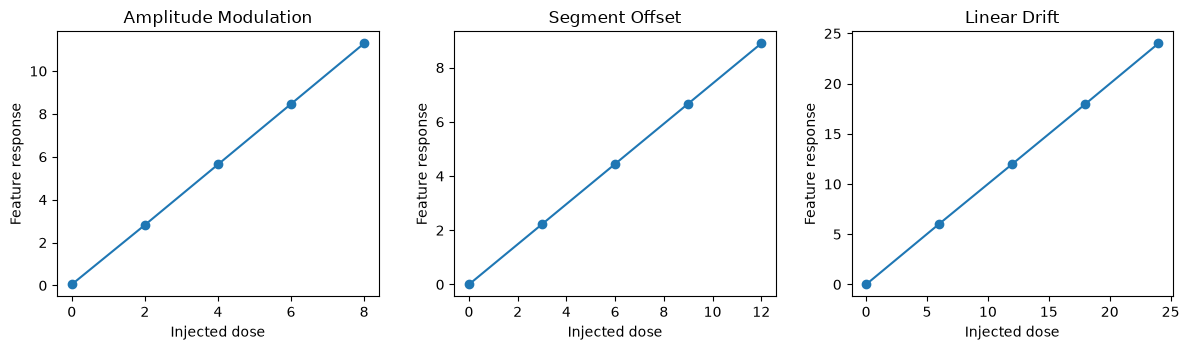

In [5]:
time = np.arange(len(base_waveform)) / FS
rows = []
for dose in [0, 2, 4, 6, 8]:
    result = extract_qgain(
        apply_level_envelope_db(base_waveform, dose*np.sin(2*np.pi*0.7*time)), FS,
        strict_speech=base_intervals, logical_recording_id=f"am_{dose}",
    ).recording
    rows.append({"mechanism":"amplitude_modulation", "dose":dose, "response":result["qgain_within_segment_iqr_db"]})
for dose in [0, 3, 6, 9, 12]:
    envelope = np.zeros(len(base_waveform))
    envelope[int(6*FS):int(12*FS)] = dose/2
    envelope[int(12*FS):] = dose
    result = extract_qgain(
        apply_level_envelope_db(base_waveform, envelope), FS,
        strict_speech=base_intervals, logical_recording_id=f"offset_{dose}",
    ).recording
    rows.append({"mechanism":"segment_offset", "dose":dose, "response":result["qgain_between_segment_mad_db"]})
for dose in [0, 6, 12, 18, 24]:
    result = extract_qgain(
        apply_level_envelope_db(base_waveform, dose*time/60), FS,
        strict_speech=base_intervals, logical_recording_id=f"drift_{dose}",
    ).recording
    rows.append({"mechanism":"linear_drift", "dose":dose, "response":result["qgain_abs_drift_db_per_min"]})
dose_response = pd.DataFrame(rows)
save_table(dose_response, VALIDATION / "qgain_v400_g4_dose_response")

g4 = pd.DataFrame([
    {"gate":"G4", "check":"within IQR orders modulation dose", "passed":dose_response.query("mechanism == 'amplitude_modulation'")["response"].is_monotonic_increasing},
    {"gate":"G4", "check":"between MAD orders segment-offset dose", "passed":dose_response.query("mechanism == 'segment_offset'")["response"].is_monotonic_increasing},
    {"gate":"G4", "check":"drift recovers injected dB/min", "passed":np.max(np.abs(dose_response.query("mechanism == 'linear_drift'")["response"] - dose_response.query("mechanism == 'linear_drift'")["dose"])) < 0.25},
])
save_table(g4, VALIDATION / "qgain_v400_g4_checks")
display(g4)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, mechanism in zip(axes, ["amplitude_modulation","segment_offset","linear_drift"]):
    local = dose_response.query("mechanism == @mechanism")
    ax.plot(local["dose"], local["response"], "o-")
    ax.set_title(mechanism.replace("_", " ").title())
    ax.set_xlabel("Injected dose")
    ax.set_ylabel("Feature response")
fig.tight_layout()
fig.savefig(FIGURES / "qgain_v400_g4_dose_response.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. G5 — discriminant controls and source non-identifiability

QGAIN cannot distinguish a device-gain envelope from an identical speaker-level
envelope because both multiply the waveform. This is not a failed estimator;
it is a physical identifiability limit. The pass criterion is that the notebook
demonstrates the limit and the registry/manuscript do not make source-specific
claims.


In [6]:
# Identical observed waveform under two different causal labels.
envelope_db = 6*np.sin(2*np.pi*0.25*time) + 8*time/60
speaker_intensity_scenario = apply_level_envelope_db(base_waveform, envelope_db)
device_gain_scenario = apply_level_envelope_db(base_waveform, envelope_db)
assert np.array_equal(speaker_intensity_scenario, device_gain_scenario)

speaker_result = extract_qgain(speaker_intensity_scenario, FS, strict_speech=base_intervals, logical_recording_id="speaker_intensity").recording
device_result = extract_qgain(device_gain_scenario, FS, strict_speech=base_intervals, logical_recording_id="device_gain").recording

identifiability = pd.DataFrame([
    {"causal_label":"speaker_intensity_change", **{f:speaker_result[f] for f in ANALYSIS_FEATURES}},
    {"causal_label":"device_gain_change", **{f:device_result[f] for f in ANALYSIS_FEATURES}},
])
save_table(identifiability, VALIDATION / "qgain_v400_g5_nonidentifiability_demo")

# Piecewise spectral changes at exactly constant RMS. Frequencies are selected
# so that every 40-ms frame contains an integer number of cycles; spectral
# content changes while the intended amplitude context does not.
frequency_switch = np.zeros_like(base_waveform)
third = len(frequency_switch)//3
for start, stop, frequency in [(0,third,200),(third,2*third,400),(2*third,len(frequency_switch),800)]:
    local_t = np.arange(stop-start) / FS
    frequency_switch[start:stop] = 0.03*np.sqrt(2)*np.sin(2*np.pi*frequency*local_t)
spectral_result = extract_qgain(frequency_switch, FS, strict_speech=base_intervals, logical_recording_id="constant_rms_spectral_change").recording
spectral_false_response = max(abs(spectral_result[f]) for f in ANALYSIS_FEATURES[1:])

registry_claims_bounded = (
    registry["claim_limit"].str.contains("not|cannot", case=False, regex=True).all()
    and not registry["standalone_gate_allowed"].any()
)
g5 = pd.DataFrame([
    {"gate":"G5", "check":"different causal labels produce identical observable/features", "passed":all(speaker_result[f] == device_result[f] for f in ANALYSIS_FEATURES)},
    {"gate":"G5", "check":"registry enforces bounded non-gating claims", "passed":registry_claims_bounded},
    {"gate":"G5", "check":"constant-RMS spectral changes do not create false level dynamics", "passed":spectral_false_response < 1e-6, "maximum_false_dynamic_response":spectral_false_response},
])
save_table(g5, VALIDATION / "qgain_v400_g5_checks")
display(identifiability)
display(g5)


,causal_label,qgain_typical_speech_level_dbfs,qgain_within_segment_iqr_db,qgain_between_segment_mad_db,qgain_abs_drift_db_per_min
0,speaker_intensity_change,-29.770874,5.894613,2.39688,8.049815
1,device_gain_change,-29.770874,5.894613,2.39688,8.049815


,gate,check,passed,maximum_false_dynamic_response
0,G5,different causal labels produce identical obse...,True,NaN
1,G5,registry enforces bounded non-gating claims,True,NaN
2,G5,constant-RMS spectral changes do not create fa...,True,4.618528e-14


## 6. G6 — support, floor, boundary, and weighting robustness


In [7]:
# Independent-support grid. Eligibility is evaluated using guarded support,
# not raw interval duration.
support_rows = []
for duration in [0.5, 0.9, 1.0, 1.39, 1.40, 2.0, 3.0, 5.0, 10.0, 18.0]:
    waveform = carrier(duration)
    result = extract_qgain(
        waveform, FS, strict_speech=[TimeInterval(0, duration)],
        logical_recording_id=f"support_{duration}",
    ).recording
    support_rows.append({
        "raw_duration_sec":duration,
        "guarded_support_sec":result["qgain_guarded_speech_support_sec"],
        **{f:result[f] for f in ANALYSIS_FEATURES},
        **{f+"_status":result[f+"_status"] for f in ANALYSIS_FEATURES},
    })
support_grid = pd.DataFrame(support_rows)
save_table(support_grid, VALIDATION / "qgain_v400_g6_support_grid")

segment_support_rows = []
long_waveform = carrier(40.0)
for segment_count in [1, 2, 3, 5, 8]:
    starts = np.linspace(1.0, 35.0, segment_count)
    local_intervals = [TimeInterval(float(start), float(start+1.0)) for start in starts]
    result = extract_qgain(
        long_waveform, FS, strict_speech=local_intervals,
        logical_recording_id=f"segments_{segment_count}",
    ).recording
    segment_support_rows.append({
        "segment_count_requested":segment_count,
        "segment_count_usable":result["qgain_usable_segment_count"],
        "time_span_sec":result["qgain_original_time_span_sec"],
        **{f:result[f] for f in ANALYSIS_FEATURES},
        **{f+"_status":result[f+"_status"] for f in ANALYSIS_FEATURES},
    })
segment_support = pd.DataFrame(segment_support_rows)
save_table(segment_support, VALIDATION / "qgain_v400_g6_segment_count_span_grid")

floor_rows = []
for fraction in [0, .005, .01, .02, .03, .05, .10]:
    waveform = base_waveform.copy()
    width = int(round(fraction*len(waveform)))
    waveform[len(waveform)//2:len(waveform)//2+width] = 0
    result = extract_qgain(waveform, FS, strict_speech=base_intervals, logical_recording_id=f"floor_{fraction}").recording
    floor_rows.append({"injected_fraction":fraction, "observed_floor_fraction":result["qgain_floor_frame_fraction"], "floor_contaminated":result["qgain_floor_contaminated"]})
floor_grid = pd.DataFrame(floor_rows)
save_table(floor_grid, VALIDATION / "qgain_v400_g6_floor_grid")

guard_rows = []
for guard_ms in [0, 50, 100, 200, 300, 400]:
    result = extract_qgain(base_waveform, FS, strict_speech=base_intervals, logical_recording_id=f"guard_{guard_ms}", guard_ms=guard_ms).recording
    guard_rows.append({"guard_ms":guard_ms, **{f:result[f] for f in ANALYSIS_FEATURES}, "support_sec":result["qgain_guarded_speech_support_sec"]})
guard_grid = pd.DataFrame(guard_rows)
save_table(guard_grid, VALIDATION / "qgain_v400_g6_guard_grid")

below_support = support_grid["guarded_support_sec"] < PARAMETERS.minimum_speech_support_sec
at_or_above_support = support_grid["guarded_support_sec"] >= PARAMETERS.minimum_speech_support_sec
below_segment_count = segment_support["segment_count_usable"] < PARAMETERS.between_minimum_segment_count
above_segment_count = segment_support["segment_count_usable"] >= PARAMETERS.between_minimum_segment_count
g6 = pd.DataFrame([
    {"gate":"G6", "check":"below-minimum guarded support is unavailable", "passed":support_grid.loc[below_support, ANALYSIS_FEATURES[0]+"_status"].eq("insufficient_support").all()},
    {"gate":"G6", "check":"minimum guarded support enables frame-based measures", "passed":support_grid.loc[at_or_above_support, ANALYSIS_FEATURES[0]].notna().all()},
    {"gate":"G6", "check":"between-segment MAD unavailable below three usable segments", "passed":segment_support.loc[below_segment_count, "qgain_between_segment_mad_db"].isna().all()},
    {"gate":"G6", "check":"between-segment MAD available at/above three usable segments", "passed":segment_support.loc[above_segment_count, "qgain_between_segment_mad_db"].notna().all()},
    {"gate":"G6", "check":"above-ceiling floor mixtures are censored", "passed":floor_grid.loc[floor_grid["observed_floor_fraction"] > PARAMETERS.maximum_floor_frame_fraction, "floor_contaminated"].all()},
    {"gate":"G6", "check":"segment-balanced audit companions exist", "passed":all(k in base.recording for k in ["qgain_typical_level_segment_balance_delta_db","qgain_within_iqr_segment_balance_delta_db"])},
])
save_table(g6, VALIDATION / "qgain_v400_g6_checks")
display(g6)


,gate,check,passed
0,G6,below-minimum guarded support is unavailable,True
1,G6,minimum guarded support enables frame-based me...,True
2,G6,between-segment MAD unavailable below three us...,True
3,G6,between-segment MAD available at/above three u...,True
4,G6,above-ceiling floor mixtures are censored,True
5,G6,segment-balanced audit companions exist,True


## 7. Frozen cohort input and optional reviewed extraction


In [8]:
def resolve_table(stem: Path) -> Path:
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(stem)


def as_bool(series: pd.Series) -> pd.Series:
    return series.map(
        lambda value: value if isinstance(value, bool)
        else str(value).strip().lower() in {"1", "true", "yes", "y"}
    )


def resolve_media_path(raw_path: object) -> Path:
    raw = str(raw_path)
    if raw in MEDIA_PATH_MAP:
        candidate = Path(MEDIA_PATH_MAP[raw]).expanduser()
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f"Mapped media path does not exist: {candidate}")
    direct = Path(raw).expanduser()
    if direct.exists():
        return direct
    if MEDIA_ROOT_OVERRIDE is not None:
        parts = list(PureWindowsPath(raw).parts)
        marker = next((i for i, part in enumerate(parts) if part.lower() == "bamboo_passage_only"), None)
        relative_parts = parts[marker + 1:] if marker is not None else [PureWindowsPath(raw).name]
        candidate = Path(MEDIA_ROOT_OVERRIDE).expanduser().joinpath(*relative_parts)
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f"Resolved override path does not exist: {candidate}")
    raise FileNotFoundError(
        f"Frozen media path does not resolve: {raw}. Set MEDIA_ROOT_OVERRIDE or MEDIA_PATH_MAP."
    )

DATA_FREEZE = LEGACY_MAIN / "00_DATA_FREEZE" / "v1"
SEG_FREEZE = LEGACY_MAIN / "01_SEGMENTATION_FREEZE" / "v1"
recordings_path = DATA_FREEZE / "frozen_bamboo_recordings.csv"
decisions_path = SEG_FREEZE / "frozen_segmentation_decisions.csv"
intervals_path = SEG_FREEZE / "frozen_segmentation_intervals.csv"

input_contract = pd.DataFrame([
    {"artifact":"recordings", "path":str(recordings_path), "exists":recordings_path.exists(), "sha256":sha256(recordings_path) if recordings_path.exists() else None},
    {"artifact":"segmentation decisions", "path":str(decisions_path), "exists":decisions_path.exists(), "sha256":sha256(decisions_path) if decisions_path.exists() else None},
    {"artifact":"segmentation intervals", "path":str(intervals_path), "exists":intervals_path.exists(), "sha256":sha256(intervals_path) if intervals_path.exists() else None},
])
save_table(input_contract, VALIDATION / "qgain_v400_g1_input_contract")

if input_contract["exists"].all():
    recordings_preview = pd.read_csv(recordings_path)
    decisions_preview = pd.read_csv(decisions_path)
    intervals_preview = pd.read_csv(intervals_path)
    eligible_preview = as_bool(decisions_preview["segmentation_analysis_eligible"]) if "segmentation_analysis_eligible" in decisions_preview else pd.Series(False, index=decisions_preview.index)
    available_views = set(intervals_preview.get("view", pd.Series(dtype=str)).dropna().astype(str))
    strict_view_available = bool(available_views.intersection({"primary_speech","strict_speech","final_speech","speech"}))
    g1_inputs = pd.DataFrame([
        {"gate":"G1", "check":"all frozen input artifacts exist and are hashed", "passed":input_contract["exists"].all() and input_contract["sha256"].notna().all()},
        {"gate":"G1", "check":"frozen decisions expose segmentation_analysis_eligible", "passed":"segmentation_analysis_eligible" in decisions_preview},
        {"gate":"G1", "check":"eligible recording identities are unique", "passed":not decisions_preview.loc[eligible_preview, "logical_recording_id"].astype(str).duplicated().any()},
        {"gate":"G1", "check":"strict/primary speech view is available", "passed":strict_view_available, "available_views":";".join(sorted(available_views))},
    ])
else:
    g1_inputs = pd.DataFrame([{
        "gate":"G1", "check":"frozen input artifacts available", "passed":False, "status":"missing_legacy_freeze"
    }])
save_table(g1_inputs, VALIDATION / "qgain_v400_g1_input_checks")
display(input_contract)
display(g1_inputs)

recording_table = pd.DataFrame()
frame_ledger = pd.DataFrame()
segment_ledger = pd.DataFrame()
extraction_errors = pd.DataFrame()

if RUN_COHORT_EXTRACTION:
    recordings = pd.read_csv(recordings_path)
    decisions = pd.read_csv(decisions_path)
    intervals = pd.read_csv(intervals_path)
    if "segmentation_analysis_eligible" not in decisions:
        raise ValueError("Frozen decisions lack segmentation_analysis_eligible")
    eligible_ids = (
        decisions.loc[as_bool(decisions["segmentation_analysis_eligible"]), ["logical_recording_id"]]
        .astype({"logical_recording_id": str})
        .drop_duplicates()
    )
    recordings["logical_recording_id"] = recordings["logical_recording_id"].astype(str)
    intervals["logical_recording_id"] = intervals["logical_recording_id"].astype(str)
    frozen = eligible_ids.merge(
        recordings.drop_duplicates("logical_recording_id"),
        on="logical_recording_id", how="left", validate="one_to_one"
    )

    def intervals_for_recording(recording_id: str) -> list[TimeInterval]:
        local = intervals.loc[
            intervals["logical_recording_id"].astype(str).eq(str(recording_id))
            & intervals["view"].astype(str).isin(["primary_speech", "strict_speech", "final_speech", "speech"])
        ]
        return [TimeInterval(float(r.start_sec), float(r.end_sec)) for r in local.itertuples()]

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required for cohort extraction")

    rows, frame_parts, segment_parts, errors = [], [], [], []
    for index, row in frozen.reset_index(drop=True).iterrows():
        recording_id = str(row["logical_recording_id"])
        try:
            media_path = resolve_media_path(row["media_path"])
            expected_media_sha256 = row.get("media_sha256")
            actual_media_sha256 = sha256(media_path) if VERIFY_MEDIA_HASHES else None
            if VERIFY_MEDIA_HASHES and pd.notna(expected_media_sha256) and str(expected_media_sha256) != actual_media_sha256:
                raise RuntimeError("Resolved media hash does not match frozen media_sha256")
            views = decode_audio_views(media_path, ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
            speech = intervals_for_recording(recording_id)
            if not speech:
                raise ValueError("No frozen strict/primary speech intervals for recording")
            result = extract_qgain(
                views.analysis_16k, FS, strict_speech=speech, logical_recording_id=recording_id,
                signal_provenance={
                    "signal_view":"mono_global_dc_removed_resampled_16k; framewise_mean_removed_AC_RMS",
                    "source_decode":"ffmpeg_f32le",
                    "amplitude_normalization_applied":False,
                    "denoising_applied":False,
                    "dynamic_range_processing_applied":False,
                    "native_sample_rate_hz":views.sample_rate_native,
                    "native_channels":views.native.shape[1],
                    "codec_name":views.probe.get("codec_name"),
                },
            )
            rows.append({
                **result.recording,
                "subject":row.get("subject", row.get("SubjectID")),
                "diagnosis_analysis":row.get("diagnosis_analysis"),
                "recording_date_analysis":row.get("recording_date_analysis"),
                "media_sha256_frozen":row.get("media_sha256"),
                "media_sha256_verified":actual_media_sha256,
            })
            frame_parts.append(result.frame_ledger)
            segment_parts.append(result.segment_ledger)
        except Exception as exc:
            errors.append({"logical_recording_id":recording_id, "error_type":type(exc).__name__, "error":str(exc)})
        if (index + 1) % 25 == 0:
            print(f"{index+1}/{len(frozen)}")

    recording_table = pd.DataFrame(rows)
    frame_ledger = pd.concat(frame_parts, ignore_index=True) if frame_parts else pd.DataFrame()
    segment_ledger = pd.concat(segment_parts, ignore_index=True) if segment_parts else pd.DataFrame()
    extraction_errors = pd.DataFrame(errors)
    save_table(recording_table, TABLES / "qgain_v400_recording_features")
    save_table(frame_ledger, TABLES / "qgain_v400_frame_ledger")
    save_table(segment_ledger, TABLES / "qgain_v400_segment_ledger")
    save_table(extraction_errors, AUDIT / "qgain_v400_extraction_errors")


,artifact,path,exists,sha256
0,recordings,C:\Users\musikicn\Desktop\Nevena_project\Paper...,True,96d68c52b5f36ef3ba1a3d0ee6ca879fce036fb449c5a6...
1,segmentation decisions,C:\Users\musikicn\Desktop\Nevena_project\Paper...,True,625a9b7306f31e4f7dcc38dca4d357dc6ffff00fc464bb...
2,segmentation intervals,C:\Users\musikicn\Desktop\Nevena_project\Paper...,True,800289777f8f6f6707794bce83b59a69ec3ca219999365...


,gate,check,passed,available_views
0,G1,all frozen input artifacts exist and are hashed,True,NaN
1,G1,frozen decisions expose segmentation_analysis_...,True,NaN
2,G1,eligible recording identities are unique,True,NaN
3,G1,strict/primary speech view is available,True,primary_speech;raw_speech;strict_internal_nons...


25/519
50/519
75/519
100/519
125/519
150/519
175/519
200/519
225/519
250/519
275/519
300/519
325/519
350/519
375/519
400/519
425/519
450/519
475/519
500/519


## 8. G7–G8 — empirical plausibility, robustness, persistence, and redundancy


In [9]:
g6_cohort_rows, g7_rows, g8_rows = [], [], []
robustness_errors = pd.DataFrame()
gallery_index = pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_table):
    summary = []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(recording_table[feature], errors="coerce")
        summary.append({
            "feature":feature,
            "recording_count":len(values),
            "available_count":int(values.notna().sum()),
            "available_fraction":float(values.notna().mean()),
            "median":float(values.median()),
            "q25":float(values.quantile(.25)),
            "q75":float(values.quantile(.75)),
            "p01":float(values.quantile(.01)),
            "p99":float(values.quantile(.99)),
            "zero_fraction":float(values.eq(0).mean()),
        })
    empirical = pd.DataFrame(summary)
    save_table(empirical, TABLES / "qgain_v400_empirical_summary")
    correlations = recording_table[list(ANALYSIS_FEATURES)].corr(method="spearman")
    correlations.to_csv(TABLES / "qgain_v400_spearman_correlations.csv")

    migration = pd.DataFrame()
    if len(legacy):
        comparison = recording_table.merge(
            legacy[["logical_recording_id", *ANALYSIS_FEATURES]],
            on="logical_recording_id", suffixes=("_v400", "_v31"), validate="one_to_one"
        )
        migration_rows = []
        for feature in ANALYSIS_FEATURES:
            delta = comparison[f"{feature}_v400"] - comparison[f"{feature}_v31"]
            migration_rows.append({
                "feature":feature,
                "n_compared":int(delta.notna().sum()),
                "median_signed_delta":float(delta.median()),
                "median_abs_delta":float(delta.abs().median()),
                "p95_abs_delta":float(delta.abs().quantile(.95)),
                "max_abs_delta":float(delta.abs().max()),
            })
        migration = pd.DataFrame(migration_rows)
        save_table(migration, VALIDATION / "qgain_v400_migration_from_v31")

    sample_step = max(1, len(recording_table)//50)
    sample_ids = recording_table.sort_values("logical_recording_id")["logical_recording_id"].iloc[::sample_step].head(50)
    permutation_rows = []
    for rid in sample_ids:
        local = segment_ledger.loc[segment_ledger["logical_recording_id"].eq(rid)]
        permutation_rows.append({"logical_recording_id":rid, **permutation_drift_audit(local, iterations=PARAMETERS.drift_permutation_iterations, seed=PARAMETERS.random_seed)})
    permutation = pd.DataFrame(permutation_rows)
    save_table(permutation, VALIDATION / "qgain_v400_drift_time_order_permutation")

    deletion_rows, boundary_rows, robustness_error_rows = [], [], []
    if RUN_COHORT_ROBUSTNESS:
        sample_count = min(MAX_ROBUSTNESS_RECORDINGS, len(frozen))
        robust_indices = np.linspace(0, len(frozen)-1, sample_count, dtype=int)
        robust_ids = frozen.sort_values("logical_recording_id").iloc[robust_indices]["logical_recording_id"].astype(str)
        frozen_by_id = frozen.set_index("logical_recording_id")
        for rid in robust_ids:
            try:
                source_row = frozen_by_id.loc[rid]
                views = decode_audio_views(resolve_media_path(source_row["media_path"]), ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
                speech = intervals_for_recording(rid)
                reference = extract_qgain(views.analysis_16k, FS, strict_speech=speech, logical_recording_id=rid).recording
                if len(speech) > 1:
                    for deleted_index in range(len(speech)):
                        alternative_intervals = [item for index, item in enumerate(speech) if index != deleted_index]
                        alternative = extract_qgain(views.analysis_16k, FS, strict_speech=alternative_intervals, logical_recording_id=rid).recording
                        for feature in ANALYSIS_FEATURES:
                            ref_value, alt_value = reference[feature], alternative[feature]
                            deletion_rows.append({
                                "logical_recording_id":rid,
                                "deleted_segment_index":deleted_index,
                                "feature":feature,
                                "reference":ref_value,
                                "alternative":alt_value,
                                "absolute_change":abs(alt_value-ref_value) if np.isfinite(ref_value) and np.isfinite(alt_value) else np.nan,
                                "availability_changed":np.isfinite(ref_value) != np.isfinite(alt_value),
                            })
                for alternative_guard in [100.0, 300.0]:
                    alternative = extract_qgain(views.analysis_16k, FS, strict_speech=speech, logical_recording_id=rid, guard_ms=alternative_guard).recording
                    for feature in ANALYSIS_FEATURES:
                        ref_value, alt_value = reference[feature], alternative[feature]
                        boundary_rows.append({
                            "logical_recording_id":rid,
                            "reference_guard_ms":PARAMETERS.speech_edge_guard_ms,
                            "alternative_guard_ms":alternative_guard,
                            "feature":feature,
                            "reference":ref_value,
                            "alternative":alt_value,
                            "absolute_change":abs(alt_value-ref_value) if np.isfinite(ref_value) and np.isfinite(alt_value) else np.nan,
                            "availability_changed":np.isfinite(ref_value) != np.isfinite(alt_value),
                        })
            except Exception as exc:
                robustness_error_rows.append({"logical_recording_id":rid, "error_type":type(exc).__name__, "error":str(exc)})
    segment_deletion = pd.DataFrame(deletion_rows)
    boundary_sensitivity = pd.DataFrame(boundary_rows)
    robustness_errors = pd.DataFrame(robustness_error_rows)
    save_table(segment_deletion, VALIDATION / "qgain_v400_segment_delete_one_long")
    save_table(boundary_sensitivity, VALIDATION / "qgain_v400_boundary_guard_sensitivity")
    save_table(robustness_errors, AUDIT / "qgain_v400_robustness_errors")
    audited_features = set(segment_deletion.get("feature", pd.Series(dtype=str))) | set(boundary_sensitivity.get("feature", pd.Series(dtype=str)))
    g6_cohort_rows.extend([
        {"gate":"G6", "check":"cohort segment-deletion and boundary robustness covers all features", "passed":audited_features == set(ANALYSIS_FEATURES)},
        {"gate":"G6", "check":"cohort robustness completed without extraction errors", "passed":robustness_errors.empty},
    ])

    long_measurements = measurement_long_frame(recording_table)
    model_ready = model_interface_frame(recording_table)
    save_table(long_measurements, TABLES / "qgain_v400_measurements_long")
    save_table(model_ready, TABLES / "qgain_v400_model_interface")

    persistence_rows = []
    try:
        import statsmodels.formula.api as smf
        for feature in ANALYSIS_FEATURES:
            local = recording_table[["subject", feature]].dropna().copy()
            counts = local.groupby("subject").size()
            local = local.loc[local["subject"].isin(counts[counts >= 2].index)]
            pair_differences = []
            for _, group in local.groupby("subject"):
                values = group[feature].to_numpy(float)
                pair_differences.extend(abs(values[i]-values[j]) for i in range(len(values)) for j in range(i+1, len(values)))
            row = {
                "feature":feature,
                "subjects_with_repeats":int(local["subject"].nunique()),
                "recordings_in_repeated_subjects":int(len(local)),
                "pair_count":int(len(pair_differences)),
                "median_within_subject_abs_difference":float(np.median(pair_differences)) if pair_differences else np.nan,
                "p90_within_subject_abs_difference":float(np.quantile(pair_differences, .90)) if pair_differences else np.nan,
                "icc_random_intercept":np.nan,
                "model_status":"insufficient_repeats",
            }
            if local["subject"].nunique() >= 3 and len(local) >= 6:
                try:
                    fit = smf.mixedlm(f"{feature} ~ 1", data=local, groups=local["subject"]).fit(reml=True, method="lbfgs", disp=False)
                    between = float(fit.cov_re.iloc[0,0])
                    residual = float(fit.scale)
                    row["icc_random_intercept"] = between/(between+residual) if between+residual > 0 else np.nan
                    row["model_status"] = "fit"
                except Exception as exc:
                    row["model_status"] = f"fit_failed:{type(exc).__name__}"
            persistence_rows.append(row)
    except Exception as exc:
        persistence_rows.append({"feature":"ALL", "model_status":f"statsmodels_unavailable:{type(exc).__name__}"})
    persistence = pd.DataFrame(persistence_rows)
    save_table(persistence, VALIDATION / "qgain_v400_repeated_recording_persistence")

    gallery_rows, gallery_errors = [], []
    if BUILD_GALLERY:
        selections = []
        for feature in ANALYSIS_FEATURES:
            local = recording_table.loc[pd.to_numeric(recording_table[feature], errors="coerce").notna()]
            for quantile in [.05, .50, .95]:
                if len(local):
                    target = local[feature].quantile(quantile)
                    idx = (local[feature]-target).abs().idxmin()
                    selections.append((str(local.loc[idx,"logical_recording_id"]), f"{feature}_q{int(100*quantile):02d}"))
        selection_frame = pd.DataFrame(selections, columns=["logical_recording_id","selection_reason"])
        if len(selection_frame):
            selection_frame = selection_frame.groupby("logical_recording_id", as_index=False)["selection_reason"].agg(";".join).head(MAX_GALLERY_RECORDINGS)
            frozen_by_id = frozen.set_index("logical_recording_id")
            for selection in selection_frame.itertuples(index=False):
                rid, reason = str(selection.logical_recording_id), str(selection.selection_reason)
                try:
                    source_row = frozen_by_id.loc[rid]
                    views = decode_audio_views(resolve_media_path(source_row["media_path"]), ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
                    extraction = extract_qgain(views.analysis_16k, FS, strict_speech=intervals_for_recording(rid), logical_recording_id=rid)
                    sample_time = np.arange(len(views.analysis_16k))/FS
                    stride = max(1, len(sample_time)//12000)
                    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
                    axes[0].plot(sample_time[::stride], views.analysis_16k[::stride], linewidth=.5)
                    axes[0].set_ylabel("Amplitude")
                    axes[0].set_title(f"{rid} — {reason}")
                    frames_local = extraction.frame_ledger
                    axes[1].scatter(frames_local["frame_mid_sec"], frames_local["ac_rms_dbfs"], s=4, alpha=.45)
                    axes[1].set_ylabel("40-ms AC-RMS (dBFS)")
                    segments_local = extraction.segment_ledger.loc[extraction.segment_ledger["usable_segment"]]
                    axes[2].plot(segments_local["segment_mid_sec"], segments_local["segment_level_median_dbfs"], "o-")
                    axes[2].set_ylabel("Segment median (dBFS)")
                    axes[2].set_xlabel("Original recording time (s)")
                    fig.tight_layout()
                    target = GALLERIES / f"qgain_gallery_{rid}.png"
                    fig.savefig(target, dpi=200, bbox_inches="tight")
                    plt.close(fig)
                    gallery_rows.append({"logical_recording_id":rid, "selection_reason":reason, "figure":str(target)})
                except Exception as exc:
                    gallery_errors.append({"logical_recording_id":rid, "selection_reason":reason, "error":str(exc)})
    gallery_index = pd.DataFrame(gallery_rows)
    gallery_error_table = pd.DataFrame(gallery_errors)
    save_table(gallery_index, GALLERIES / "qgain_gallery_index")
    save_table(gallery_error_table, AUDIT / "qgain_gallery_errors")

    g7_rows.extend([
        {"gate":"G7", "check":"all four empirical distributions summarized", "passed":len(empirical) == 4},
        {"gate":"G7", "check":"support/status fields present", "passed":all(f+"_status" in recording_table for f in ANALYSIS_FEATURES)},
        {"gate":"G7", "check":"label-blind signal-linked gallery created without errors", "passed":len(gallery_index) >= 4 and gallery_error_table.empty},
    ])
    g8_rows.extend([
        {"gate":"G8", "check":"no exact duplicate feature columns", "passed":not any(recording_table[a].equals(recording_table[b]) for i,a in enumerate(ANALYSIS_FEATURES) for b in ANALYSIS_FEATURES[i+1:])},
        {"gate":"G8", "check":"ML interface contains values and masks", "passed":all(f+"_available" in model_ready for f in ANALYSIS_FEATURES)},
        {"gate":"G8", "check":"repeated-recording persistence quantified for all features", "passed":set(persistence.get("feature", pd.Series(dtype=str))) == set(ANALYSIS_FEATURES)},
        {"gate":"G8", "check":"drift time-order permutation audit completed", "passed":len(permutation) > 0 and permutation["permutation_pvalue"].notna().any()},
        {"gate":"G8", "check":"official ITU-T P.56 comparator pinned and executed", "passed":False, "status":"pending_official_G191_STL_integration"},
    ])
else:
    g6_cohort_rows.append({"gate":"G6", "check":"cohort support/boundary robustness", "passed":False, "status":"pending_local_run"})
    g7_rows.append({"gate":"G7", "check":"cohort extraction and empirical gallery", "passed":False, "status":"pending_local_run"})
    g8_rows.append({"gate":"G8", "check":"cohort persistence/redundancy", "passed":False, "status":"pending_local_run"})

g6_cohort = pd.DataFrame(g6_cohort_rows)
g7 = pd.DataFrame(g7_rows)
g8 = pd.DataFrame(g8_rows)
save_table(g6_cohort, VALIDATION / "qgain_v400_g6_cohort_checks")
save_table(g7, VALIDATION / "qgain_v400_g7_checks")
save_table(g8, VALIDATION / "qgain_v400_g8_checks")
display(g6_cohort)
display(g7)
display(g8)


C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,gate,check,passed
0,G6,cohort segment-deletion and boundary robustnes...,True
1,G6,cohort robustness completed without extraction...,True


,gate,check,passed
0,G7,all four empirical distributions summarized,True
1,G7,support/status fields present,True
2,G7,label-blind signal-linked gallery created with...,True


,gate,check,passed,status
0,G8,no exact duplicate feature columns,True,NaN
1,G8,ML interface contains values and masks,True,NaN
2,G8,repeated-recording persistence quantified for ...,True,NaN
3,G8,drift time-order permutation audit completed,True,NaN
4,G8,official ITU-T P.56 comparator pinned and exec...,False,pending_official_G191_STL_integration


## 9. G9 — event verification

Not applicable. QGAIN v4 contains no event detector. The v3.0 local-transition
metric remains a documented negative result and is absent from the reviewed
module, registry, cohort table, and ML interface.


In [10]:
g9 = pd.DataFrame([{
    "gate":"G9", "check":"event verification", "passed":True,
    "status":"not_applicable_no_event_feature",
}])
save_table(g9, VALIDATION / "qgain_v400_g9_checks")
display(g9)


,gate,check,passed,status
0,G9,event verification,True,not_applicable_no_event_feature


## 10. G10 — feature-specific decision and candidate freeze gate


In [11]:
feature_decisions = pd.DataFrame([
    {"feature":"qgain_typical_speech_level_dbfs", "proposed_decision":"retain_contextual", "publication_claim":"analysis-view operating-level context only", "standalone_gate_allowed":False},
    {"feature":"qgain_within_segment_iqr_db", "proposed_decision":"retain_with_high_confounding", "publication_claim":"within-segment recorded-level dispersion", "standalone_gate_allowed":False},
    {"feature":"qgain_between_segment_mad_db", "proposed_decision":"retain_with_high_confounding", "publication_claim":"between-segment recorded-level dispersion", "standalone_gate_allowed":False},
    {"feature":"qgain_abs_drift_db_per_min", "proposed_decision":"retain_with_very_high_confounding", "publication_claim":"ordered recorded-level drift; source not identifiable", "standalone_gate_allowed":False},
])
save_table(feature_decisions, VALIDATION / "qgain_v400_g10_feature_decisions")

review_accepted = SCIENTIFIC_REVIEW_DECISION == "ACCEPT_QGAIN_V400"
g10 = pd.DataFrame([{
    "gate":"G10",
    "check":"feature-specific scientific review decision accepted",
    "passed":review_accepted,
    "status":"accepted" if review_accepted else "pending_scientific_review",
}])
save_table(g10, VALIDATION / "qgain_v400_g10_checks")

all_checks = pd.concat([g1, g1_inputs, g2, g3, g4, g5, g6, g6_cohort, g7, g8, g9, g10], ignore_index=True, sort=False)
all_checks["blocking"] = all_checks["gate"].isin(["G1","G2","G3","G4","G5","G6","G7","G8","G10"])
save_table(all_checks, VALIDATION / "qgain_v400_gate_summary")

blocking_pass = bool(all_checks.loc[all_checks["blocking"], "passed"].fillna(False).all())
freeze_allowed = blocking_pass and RUN_COHORT_EXTRACTION

manifest = {
    "measurement_version":MEASUREMENT_VERSION,
    "candidate_only":not freeze_allowed,
    "blocking_checks_pass":blocking_pass,
    "cohort_extraction_completed":bool(RUN_COHORT_EXTRACTION and len(recording_table)),
    "scientific_review_decision":SCIENTIFIC_REVIEW_DECISION,
    "scientific_reviewer":SCIENTIFIC_REVIEWER,
    "scientific_review_rationale":SCIENTIFIC_REVIEW_RATIONALE,
    "freeze_allowed":freeze_allowed,
    "analysis_features":list(ANALYSIS_FEATURES),
    "standalone_reject_allowed":False,
    "decision_threshold_status":"not_calibrated",
    "parameters":PARAMETERS.to_dict(),
    "implementation_sha256":sha256(implementation_path) if implementation_path.exists() else None,
    "event_detector_present":False,
    "codec_roundtrip_required":bool(RUN_CODEC_ROUNDTRIP),
    "media_hash_verification_required":bool(VERIFY_MEDIA_HASHES),
    "cohort_robustness_required":bool(RUN_COHORT_ROBUSTNESS),
    "gallery_required":bool(BUILD_GALLERY),
    "p56_comparator_status":"pending_official_G191_STL_integration",
}
(MANIFESTS / "qgain_v400_candidate_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

display(feature_decisions)
print(json.dumps(manifest, indent=2))

if PUBLISH_AND_FREEZE and not freeze_allowed:
    raise RuntimeError("Freeze requested but blocking gates/cohort/review are incomplete.")

if freeze_allowed and PUBLISH_AND_FREEZE:
    target = MAIN_REVIEWED / "06_family_freezes" / "gain_dynamics" / "qgain-v4.0.0"
    if target.exists():
        raise RuntimeError(f"Refusing to overwrite existing reviewed freeze: {target}")
    shutil.copytree(OUTPUT_ROOT, target)
    if len(recording_table):
        save_table(recording_table, MAIN_REVIEWED / "01_analysis_features" / "qgain_v400_analysis_features")
        save_table(measurement_long_frame(recording_table), MAIN_REVIEWED / "02_support_and_availability" / "qgain_v400_measurements_long")
        save_table(model_interface_frame(recording_table), MAIN_REVIEWED / "04_model_ready_features" / "qgain_v400_model_interface")
    print(f"FROZEN: {target}")
else:
    print("Candidate run only; no publication freeze written.")


,feature,proposed_decision,publication_claim,standalone_gate_allowed
0,qgain_typical_speech_level_dbfs,retain_contextual,analysis-view operating-level context only,False
1,qgain_within_segment_iqr_db,retain_with_high_confounding,within-segment recorded-level dispersion,False
2,qgain_between_segment_mad_db,retain_with_high_confounding,between-segment recorded-level dispersion,False
3,qgain_abs_drift_db_per_min,retain_with_very_high_confounding,ordered recorded-level drift; source not ident...,False


{
  "measurement_version": "qgain-v4.0.0-candidate",
  "candidate_only": true,
  "blocking_checks_pass": false,
  "cohort_extraction_completed": true,
  "scientific_review_decision": "PENDING",
  "scientific_reviewer": "",
  "scientific_review_rationale": "",
  "freeze_allowed": false,
  "analysis_features": [
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min"
  ],
  "standalone_reject_allowed": false,
  "decision_threshold_status": "not_calibrated",
  "parameters": {
    "analysis_sample_rate_hz": 16000,
    "frame_length_ms": 40.0,
    "frame_hop_ms": 10.0,
    "speech_edge_guard_ms": 200.0,
    "dbfs_floor_db": -120.0,
    "maximum_floor_frame_fraction": 0.02,
    "minimum_speech_support_sec": 1.0,
    "minimum_valid_frame_count": 25,
    "minimum_segment_frame_count": 5,
    "between_minimum_segment_count": 3,
    "drift_minimum_segment_count": 3,
    "drift_minimum_span_sec": 10.0,
    "mod

## 11. Package tests


In [12]:
if RUN_PACKAGE_TESTS:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", str(PROJECT_ROOT / "tests reviewed" / "test_qgain_v400.py"), "-q"],
        cwd=PROJECT_ROOT,
        check=False,
        capture_output=True,
        text=True,
    )
    print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode:
        raise RuntimeError("Reviewed QGAIN package tests failed.")


................                                                         [100%]

